# DDXPlus Full-Evidence One-Shot Comparator

This notebook trains a direct diagnosis classifier under an oracle-style visibility condition: every DDXPlus root evidence field is visible as present/value or absent. It is not a deployable sequential policy and must not be used inside live workup decisions. Its purpose is to estimate the information ceiling available in DDXPlus and to compare that ceiling against the initial-evidence one-shot baseline.

Fairness rule: full-evidence predictions, probabilities, labels, and derived features are evaluation comparators only. They are not inputs to the sequential policy notebooks.

In [1]:
from __future__ import annotations

import ast
import json
import os
import random
import subprocess
import sys
import time
import zipfile
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 20)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / "scripts" / "download_ddxplus.py").exists()
    ),
    Path.cwd(),
)
DATASET_ENV_VAR = "DDXPLUS_DATASET_DIR"
DEFAULT_DATASET_DIR = ROOT / "dataset"
LEGACY_DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
DATASET_DIR = (
    Path(os.environ[DATASET_ENV_VAR]).expanduser()
    if os.environ.get(DATASET_ENV_VAR)
    else DEFAULT_DATASET_DIR
    if DEFAULT_DATASET_DIR.exists()
    else LEGACY_DATASET_DIR
    if LEGACY_DATASET_DIR.exists()
    else DEFAULT_DATASET_DIR
)
AUTO_DOWNLOAD_IF_MISSING = True
RUN_MODE = "full"  # change to "quick" for a smaller screening run
SKIP_EXISTING_RUNS = True
CANDIDATES_TO_RUN = ["full_evidence_pathology"]

RUN_CONFIGS = {
    "quick": {
        "subset": {"train": 100_000, "validate": 10_000, "test": 10_000},
        "max_epochs": 15,
        "patience": 3,
    },
    "full": {
        "subset": {"train": None, "validate": None, "test": None},
        "max_epochs": 30,
        "patience": 5,
    },
}
BASE_RUN_CONFIG = {
    "seed": 2919,
    "batch_size": 512,
    "learning_rate": 3.469e-4,
    "hidden_sizes": [2048, 2048, 2048],
    "dropout": 0.0,
    "weight_decay": 0.0,
    "num_workers": 0,
    "device": "auto",
}
CANDIDATE_CONFIGS = {
    "full_evidence_pathology": {
        "objective_name": "basd_pathology",
        "description": "Gold-pathology cross-entropy with every DDXPlus root evidence field visible.",
    },
}

ARTIFACT_ROOT = ROOT / "artifacts" / "one_shot_full_evidence"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root :", ROOT)
print("Dataset dir  :", DATASET_DIR)
print("Run mode     :", RUN_MODE)
print("Artifact root:", ARTIFACT_ROOT)
print("Candidates   :", CANDIDATES_TO_RUN)


Project root : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir  : /Users/bilalawan/claw/assignments/baseline_model/dataset
Run mode     : full
Artifact root: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence
Candidates   : ['full_evidence_pathology']


## Dataset Setup And Split Preparation

This mirrors notebook 01 so the comparator is aligned with the existing one-shot baseline. The key difference appears in the encoder: every root evidence slot is revealed instead of only `INITIAL_EVIDENCE`.

In [2]:
REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]
SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}


def ensure_dataset_present(dataset_dir: Path, auto_download: bool = True) -> dict[str, Path]:
    dataset_dir = dataset_dir.expanduser().resolve()
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing and auto_download:
        subprocess.run(
            [sys.executable, str(ROOT / "scripts" / "download_ddxplus.py"), "--output-dir", str(dataset_dir)],
            cwd=ROOT,
            check=True,
        )
        paths = {name: dataset_dir / name for name in REQUIRED_FILES}
        missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing dataset files in {dataset_dir}: {', '.join(missing)}")
    invalid_zips = [name for name, path in paths.items() if path.suffix == ".zip" and not zipfile.is_zipfile(path)]
    if invalid_zips:
        raise ValueError(
            f"Invalid or incomplete zip files in {dataset_dir}: {', '.join(invalid_zips)}. "
            "Delete the partial archives and rerun scripts/download_ddxplus.py."
        )
    return paths


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        file_name = next((name for name in members if name.endswith(".csv")), None)
        if file_name is None:
            if not members:
                raise ValueError(f"Archive is empty: {zip_path}")
            file_name = members[0]
        with archive.open(file_name) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["source_row_index"] = np.arange(len(enriched), dtype=int)
    enriched["split"] = split_name
    enriched["case_id"] = enriched["source_row_index"].map(lambda idx: f"{split_name}:{idx}")
    return enriched


def _allocate_group_counts(counts: pd.Series, sample_size: int) -> pd.Series:
    if sample_size >= int(counts.sum()):
        return counts.copy()
    raw = counts / counts.sum() * sample_size
    allocated = np.floor(raw).astype(int)
    if sample_size >= len(counts):
        allocated[allocated == 0] = 1
    allocated = np.minimum(allocated, counts.to_numpy())
    deficit = sample_size - int(allocated.sum())
    if deficit > 0:
        order = np.argsort(-(raw - allocated))
        for idx in order:
            if allocated[idx] < counts.iloc[idx]:
                allocated[idx] += 1
                deficit -= 1
            if deficit == 0:
                break
    overflow = int(allocated.sum()) - sample_size
    if overflow > 0:
        order = np.argsort(raw - allocated)
        for idx in order:
            if allocated[idx] > 1:
                allocated[idx] -= 1
                overflow -= 1
            if overflow == 0:
                break
    return pd.Series(allocated, index=counts.index, dtype=int)


def stratified_subset(frame: pd.DataFrame, label_col: str, sample_size: int | None, seed: int) -> pd.DataFrame:
    if sample_size is None or sample_size >= len(frame):
        return frame.reset_index(drop=True)
    counts = frame[label_col].value_counts().sort_index()
    allocations = _allocate_group_counts(counts, sample_size)
    rng = np.random.default_rng(seed)
    sampled_indices = []
    for label, count in allocations.items():
        if count <= 0:
            continue
        label_indices = frame.index[frame[label_col] == label].to_numpy()
        sampled_indices.append(rng.choice(label_indices, size=int(count), replace=False))
    merged = np.concatenate(sampled_indices)
    rng.shuffle(merged)
    return frame.loc[merged].reset_index(drop=True)


def sample_fixed_cases_per_pathology(frame: pd.DataFrame, label_col: str, per_class: int, seed: int) -> pd.DataFrame:
    pieces = []
    for offset, (label, group) in enumerate(frame.groupby(label_col, sort=True)):
        take = min(per_class, len(group))
        pieces.append(group.sample(n=take, random_state=seed + offset))
    sampled = pd.concat(pieces, axis=0).sort_values(["PATHOLOGY", "source_row_index"]).reset_index(drop=True)
    return sampled


## Case Episodes And BASD-Style Observation Encoding

Each patient row is compiled into a reusable case episode. For the one-shot baseline, only the root evidence group corresponding to `INITIAL_EVIDENCE` is revealed before encoding.


In [3]:
def parse_literal_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    return ast.literal_eval(raw)


def parse_evidence_token(token: str) -> tuple[str, str | None]:
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


def encode_age(age: int) -> int:
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    if sex == "M":
        return 0
    if sex == "F":
        return 1
    raise ValueError(f"Unexpected sex value: {sex}")


@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    question_text: dict[str, str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, evidence_metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(evidence_metadata.keys())
        slot_slices = {}
        data_types = {}
        possible_values = {}
        default_values = {}
        categorical_integer_roots = set()
        question_text = {}
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id in root_ids:
            meta = evidence_metadata[root_id]
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            question_text[root_id] = meta.get("question_en", root_id)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(
            root_ids=root_ids,
            slot_slices=slot_slices,
            data_types=data_types,
            possible_values=possible_values,
            default_values=default_values,
            categorical_integer_roots=categorical_integer_roots,
            question_text=question_text,
            feature_names=feature_names,
        )

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(int(age))] = 1.0
        state[8 + encode_sex(sex)] = 1.0
        return state

    def full_evidence_absent_template(self) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        for root_id in self.root_ids:
            self.apply_root_observation(state, root_id, [])
        state[:10] = 0.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            # Assumption: the official one-slot categorical path is preserved by storing
            # unknown=0 and observed category as a normalized scalar in (0, 1].
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = 0.0
                return state
            idx = self.possible_values[root_id].index(str(chosen))
            state[start] = float((idx + 1) / max(1, len(self.possible_values[root_id])))
            return state
        state[start:end] = -1.0
        selected_values = values if values else ([default_value] if default_value is not None else [])
        for value in selected_values:
            idx = self.possible_values[root_id].index(str(value))
            state[start + idx] = 1.0
        return state


@dataclass
class EvidenceLedgerEntry:
    root_evidence_id: str
    question_en: str
    source: str
    status: str
    values: list[str] = field(default_factory=list)

    def as_dict(self) -> dict[str, Any]:
        return {
            "root_evidence_id": self.root_evidence_id,
            "question_en": self.question_en,
            "source": self.source,
            "status": self.status,
            "values": list(self.values),
        }


@dataclass
class CaseEpisode:
    case_id: str
    split_name: str
    source_row_index: int
    age: int
    sex: str
    pathology: str
    initial_evidence: str
    differential: list[tuple[str, float]]
    evidence_by_root: dict[str, list[str]]
    visible_evidence: list[str]
    hidden_evidence: list[str]
    requestable_fields: list[str]
    evidence_ledger: list[EvidenceLedgerEntry]
    revealed_roots: set[str]


class CaseEpisodeCompiler:
    def __init__(self, evidence_metadata: dict[str, dict[str, Any]]):
        self.evidence_metadata = evidence_metadata
        self.schema = ObservationSchema.from_metadata(evidence_metadata)
        self.full_absent_template = self.schema.full_evidence_absent_template()
        self.current_episode: CaseEpisode | None = None

    def tokens_to_values(self, root_id: str, tokens: list[str]) -> list[str]:
        data_type = self.schema.data_types[root_id]
        if data_type == "B":
            return ["present"] if tokens else []
        return [value for _, value in map(parse_evidence_token, tokens) if value is not None]

    def from_row(self, row: Any, split_name: str | None = None) -> CaseEpisode:
        evidences_list = [str(token) for token in parse_literal_list(row["EVIDENCES"])]
        differential = parse_literal_list(row["DIFFERENTIAL_DIAGNOSIS"])
        initial_evidence = str(row["INITIAL_EVIDENCE"])
        initial_root, _ = parse_evidence_token(initial_evidence)
        evidence_by_root: dict[str, list[str]] = {}
        for token in evidences_list:
            root_id, _ = parse_evidence_token(token)
            evidence_by_root.setdefault(root_id, []).append(token)
        visible_evidence = list(evidence_by_root.get(initial_root, [initial_evidence]))
        hidden_lookup = set(visible_evidence)
        hidden_evidence = [token for token in evidences_list if token not in hidden_lookup]
        differential_pairs = [(str(pathology), float(score)) for pathology, score in differential]
        split_value = str(row.get("split", split_name or "unknown"))
        source_row_index = int(row.get("source_row_index", -1))
        case_id = str(row.get("case_id", f"{split_value}:{source_row_index}"))
        ledger = [
            EvidenceLedgerEntry(
                root_evidence_id=initial_root,
                question_en=self.schema.question_text[initial_root],
                source="initial_evidence",
                status="present",
                values=self.tokens_to_values(initial_root, visible_evidence),
            )
        ]
        episode = CaseEpisode(
            case_id=case_id,
            split_name=split_value,
            source_row_index=source_row_index,
            age=int(row["AGE"]),
            sex=str(row["SEX"]),
            pathology=str(row["PATHOLOGY"]),
            initial_evidence=initial_evidence,
            differential=differential_pairs,
            evidence_by_root=evidence_by_root,
            visible_evidence=visible_evidence,
            hidden_evidence=hidden_evidence,
            requestable_fields=list(self.schema.root_ids),
            evidence_ledger=ledger,
            revealed_roots={initial_root},
        )
        self.current_episode = episode
        return episode

    def build_initial_state(self, episode: CaseEpisode | None = None) -> np.ndarray:
        current = episode or self.current_episode
        if current is None:
            raise ValueError("No episode is loaded.")
        state = self.schema.initial_state(current.age, current.sex)
        for root_id in current.revealed_roots:
            tokens = current.evidence_by_root.get(root_id, [])
            values = self.tokens_to_values(root_id, tokens)
            self.schema.apply_root_observation(state, root_id, values)
        return state

    def build_full_state(self, episode: CaseEpisode | None = None) -> np.ndarray:
        current = episode or self.current_episode
        if current is None:
            raise ValueError("No episode is loaded.")
        state = self.full_absent_template.copy()
        state[encode_age(int(current.age))] = 1.0
        state[8 + encode_sex(current.sex)] = 1.0
        for root_id, tokens in current.evidence_by_root.items():
            values = self.tokens_to_values(root_id, tokens)
            self.schema.apply_root_observation(state, root_id, values)
        return state

    def request_evidence(self, root_evidence_id: str, episode: CaseEpisode | None = None) -> list[str]:
        current = episode or self.current_episode
        if current is None:
            raise ValueError("No episode is loaded.")
        if root_evidence_id in current.revealed_roots:
            return current.evidence_by_root.get(root_evidence_id, [])
        revealed_tokens = list(current.evidence_by_root.get(root_evidence_id, []))
        current.revealed_roots.add(root_evidence_id)
        if revealed_tokens:
            current.visible_evidence.extend(revealed_tokens)
            hidden_lookup = set(revealed_tokens)
            current.hidden_evidence = [token for token in current.hidden_evidence if token not in hidden_lookup]
            status = "present"
            values = self.tokens_to_values(root_evidence_id, revealed_tokens)
        else:
            status = "absent"
            values = []
        current.evidence_ledger.append(
            EvidenceLedgerEntry(
                root_evidence_id=root_evidence_id,
                question_en=self.schema.question_text[root_evidence_id],
                source="request",
                status=status,
                values=values,
            )
        )
        return revealed_tokens


def render_ledger(episode: CaseEpisode) -> str:
    rows = []
    for entry in episode.evidence_ledger:
        value_text = ", ".join(entry.values) if entry.values else "none"
        rows.append(f"- {entry.root_evidence_id} | {entry.status} | {value_text} | {entry.source}")
    return "\n".join(rows)


## Model, Objective Variants, And Evaluation Utilities

The architecture stays fixed across candidates. Only the objective changes, which keeps the comparison fair while still giving you a stronger one-shot benchmark suite than a single fixed model.


In [4]:
def choose_device(device_name: str) -> torch.device:
    if device_name == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(device_name)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))


def soft_cross_entropy(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    log_probs = torch.log_softmax(logits, dim=1)
    return -(targets * log_probs).sum(dim=1).mean()


def compute_objective_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    differential_targets: torch.Tensor,
    objective_name: str,
) -> torch.Tensor:
    pathology_loss = nn.functional.cross_entropy(logits, labels)
    differential_loss = soft_cross_entropy(logits, differential_targets)
    if objective_name == "basd_pathology":
        return pathology_loss
    if objective_name == "basd_differential":
        return differential_loss
    if objective_name == "basd_joint":
        return pathology_loss + 0.5 * differential_loss
    raise ValueError(f"Unsupported objective name: {objective_name}")


def top_k_accuracy(probs: np.ndarray, labels: np.ndarray, k: int) -> float:
    topk = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    hits = [int(label in row) for label, row in zip(labels, topk)]
    return float(np.mean(hits))


def macro_f1(labels: np.ndarray, predictions: np.ndarray, num_classes: int) -> float:
    scores = []
    for class_idx in range(num_classes):
        tp = np.sum((labels == class_idx) & (predictions == class_idx))
        fp = np.sum((labels != class_idx) & (predictions == class_idx))
        fn = np.sum((labels == class_idx) & (predictions != class_idx))
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        if precision + recall == 0:
            scores.append(0.0)
        else:
            scores.append((2 * precision * recall) / (precision + recall))
    return float(np.mean(scores))


def compute_ddx_metrics(probs: np.ndarray, gt_differential: np.ndarray, threshold: float = 0.01) -> dict[str, float]:
    gt_mask = gt_differential > threshold
    pred_mask = probs > threshold
    shared = gt_mask & pred_mask
    ddr = shared.sum(axis=1) / np.maximum(1, gt_mask.sum(axis=1))
    ddp = shared.sum(axis=1) / np.maximum(1, pred_mask.sum(axis=1))
    ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
    metrics = {
        "DDR": float(np.mean(ddr)),
        "DDP": float(np.mean(ddp)),
        "DDF1": float(np.mean(ddf1)),
    }
    gt_ranked = np.argsort(gt_differential, axis=1)[:, ::-1]
    pred_ranked = np.argsort(probs, axis=1)[:, ::-1]
    for k in (3, 5):
        gt_top = np.zeros_like(gt_mask, dtype=bool)
        pred_top = np.zeros_like(pred_mask, dtype=bool)
        np.put_along_axis(gt_top, gt_ranked[:, :k], True, axis=1)
        np.put_along_axis(pred_top, pred_ranked[:, :k], True, axis=1)
        gt_top &= gt_mask
        pred_top &= pred_mask
        shared_top = gt_top & pred_top
        recall_top = shared_top.sum(axis=1) / np.maximum(1, gt_top.sum(axis=1))
        precision_top = shared_top.sum(axis=1) / np.maximum(1, pred_top.sum(axis=1))
        f1_top = np.where(
            recall_top + precision_top == 0,
            0.0,
            2 * recall_top * precision_top / (recall_top + precision_top),
        )
        metrics[f"DDR@{k}"] = float(np.mean(recall_top))
        metrics[f"DDP@{k}"] = float(np.mean(precision_top))
        metrics[f"DDF1@{k}"] = float(np.mean(f1_top))
    return metrics


def compute_metrics(
    probs: np.ndarray,
    labels: np.ndarray,
    gt_differential: np.ndarray,
    label_names: list[str],
) -> dict[str, float]:
    predictions = np.argmax(probs, axis=1)
    metrics = {
        "accuracy": float(np.mean(predictions == labels)),
        "top3_accuracy": top_k_accuracy(probs, labels, 3),
        "top5_accuracy": top_k_accuracy(probs, labels, 5),
        "macro_f1": macro_f1(labels, predictions, len(label_names)),
    }
    metrics.update(compute_ddx_metrics(probs, gt_differential))
    return metrics


def build_predictions_frame(
    probs: np.ndarray,
    labels: np.ndarray,
    rows: pd.DataFrame,
    label_names: list[str],
) -> pd.DataFrame:
    predictions = np.argmax(probs, axis=1)
    top5 = np.argsort(probs, axis=1)[:, ::-1][:, :5]
    payload = rows.copy().reset_index(drop=True)
    payload["true_label_index"] = labels
    payload["pred_label_index"] = predictions
    payload["true_pathology"] = [label_names[label] for label in labels]
    payload["pred_pathology"] = [label_names[pred] for pred in predictions]
    payload["correct"] = payload["true_label_index"] == payload["pred_label_index"]
    payload["top1_confidence"] = probs[np.arange(len(probs)), predictions]
    payload["top5_predictions"] = [
        json.dumps([label_names[idx] for idx in ranked]) for ranked in top5
    ]
    payload["top5_prediction_scores"] = [
        json.dumps([float(probs[row_idx, idx]) for idx in ranked]) for row_idx, ranked in enumerate(top5)
    ]
    return payload


def summarize_confusions(prediction_frame: pd.DataFrame, top_n: int = 25) -> pd.DataFrame:
    mistakes = prediction_frame.loc[~prediction_frame["correct"], ["true_pathology", "pred_pathology"]]
    counts = Counter(tuple(item) for item in mistakes.itertuples(index=False, name=None))
    rows = [
        {"true_pathology": true_pathology, "pred_pathology": pred_pathology, "count": count}
        for (true_pathology, pred_pathology), count in counts.most_common(top_n)
    ]
    return pd.DataFrame(rows)


def select_qualitative_examples(
    probs: np.ndarray,
    labels: np.ndarray,
    rows: pd.DataFrame,
    label_names: list[str],
    max_examples: int = 8,
) -> list[dict[str, Any]]:
    prediction_frame = build_predictions_frame(probs, labels, rows, label_names)
    correct = prediction_frame[prediction_frame["correct"]].drop_duplicates("case_id").nlargest(max_examples // 2, "top1_confidence")
    incorrect = prediction_frame[~prediction_frame["correct"]].drop_duplicates("case_id").nlargest(max_examples - len(correct), "top1_confidence")
    selected = pd.concat([correct, incorrect], ignore_index=True)
    examples = []
    for row in selected.itertuples(index=False):
        examples.append(
            {
                "case_id": row.case_id,
                "age": int(row.AGE),
                "sex": row.SEX,
                "initial_evidence": row.INITIAL_EVIDENCE,
                "true_pathology": row.true_pathology,
                "predicted_pathology": row.pred_pathology,
                "top1_confidence": float(row.top1_confidence),
                "top5_predictions": json.loads(row.top5_predictions),
                "correct": bool(row.correct),
            }
        )
    return examples


def normalize_differential(
    differential: list[tuple[str, float]],
    pathology_to_index: dict[str, int],
    gold_pathology: str,
) -> np.ndarray:
    target = np.zeros(len(pathology_to_index), dtype=np.float32)
    for pathology, weight in differential:
        if pathology in pathology_to_index:
            target[pathology_to_index[pathology]] = float(weight)
    if target.sum() <= 0:
        target[pathology_to_index[gold_pathology]] = 1.0
    else:
        target /= target.sum()
    return target


def encode_split(
    frame: pd.DataFrame,
    compiler: CaseEpisodeCompiler,
    pathology_to_index: dict[str, int],
    split_name: str,
):
    features = np.zeros((len(frame), compiler.schema.feature_size), dtype=np.float32)
    labels = np.zeros(len(frame), dtype=np.int64)
    differential_targets = np.zeros((len(frame), len(pathology_to_index)), dtype=np.float32)
    metadata_rows = []
    for row_idx, row in enumerate(tqdm(frame.itertuples(index=False), total=len(frame), desc=f"Encoding {split_name}")):
        row_dict = row._asdict()
        episode = compiler.from_row(row_dict, split_name=split_name)
        features[row_idx] = compiler.build_full_state(episode)
        labels[row_idx] = pathology_to_index[episode.pathology]
        differential_targets[row_idx] = normalize_differential(
            episode.differential,
            pathology_to_index,
            episode.pathology,
        )
        metadata_rows.append(
            {
                "case_id": episode.case_id,
                "source_row_index": episode.source_row_index,
                "split": episode.split_name,
                "AGE": episode.age,
                "SEX": episode.sex,
                "PATHOLOGY": episode.pathology,
                "INITIAL_EVIDENCE": episode.initial_evidence,
                "visible_evidence_mode": "all_roots_present_or_absent",
                "num_present_evidence_roots": len(episode.evidence_by_root),
            }
        )
    return features, labels, differential_targets, pd.DataFrame(metadata_rows)


def create_loader(
    features: np.ndarray,
    labels: np.ndarray,
    differential_targets: np.ndarray,
    batch_size: int,
    shuffle: bool,
    num_workers: int,
) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(features, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long),
        torch.tensor(differential_targets, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    objective_name: str,
) -> float:
    model.train()
    total_loss = 0.0
    total_examples = 0
    for features, labels, differential_targets in loader:
        features = features.to(device)
        labels = labels.to(device)
        differential_targets = differential_targets.to(device)
        optimizer.zero_grad()
        logits = model(features)
        loss = compute_objective_loss(logits, labels, differential_targets, objective_name)
        loss.backward()
        optimizer.step()
        batch_size = features.size(0)
        total_loss += float(loss.item()) * batch_size
        total_examples += batch_size
    return total_loss / max(1, total_examples)


@torch.no_grad()
def predict(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    objective_name: str,
):
    model.eval()
    all_probs, all_labels, all_differentials = [], [], []
    total_loss = 0.0
    total_examples = 0
    for features, labels, differential_targets in loader:
        features = features.to(device)
        labels = labels.to(device)
        differential_targets = differential_targets.to(device)
        logits = model(features)
        loss = compute_objective_loss(logits, labels, differential_targets, objective_name)
        probs = torch.softmax(logits, dim=1)
        batch_size = features.size(0)
        total_loss += float(loss.item()) * batch_size
        total_examples += batch_size
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_differentials.append(differential_targets.cpu().numpy())
    return (
        np.concatenate(all_probs, axis=0),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_differentials, axis=0),
        total_loss / max(1, total_examples),
    )


def run_candidate(
    candidate_name: str,
    candidate_config: dict[str, Any],
    schema: ObservationSchema,
    label_names: list[str],
    train_loader: DataLoader,
    validate_loader: DataLoader,
    test_loader: DataLoader,
    validate_meta: pd.DataFrame,
    test_meta: pd.DataFrame,
    run_config: dict[str, Any],
    device: torch.device,
) -> dict[str, Any]:
    run_name = f"{candidate_name}_{RUN_MODE}"
    artifact_dir = ARTIFACT_ROOT / run_name
    artifact_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = artifact_dir / "metrics.json"
    predictions_path = artifact_dir / "predictions.csv"
    history_path = artifact_dir / "training_history.json"
    checkpoint_path = artifact_dir / "best_model.pt"
    if SKIP_EXISTING_RUNS and metrics_path.exists() and predictions_path.exists() and history_path.exists():
        metrics_payload = load_json(metrics_path)
        return {
            "candidate_name": candidate_name,
            "objective_name": candidate_config["objective_name"],
            "run_name": run_name,
            "artifact_dir": str(artifact_dir.resolve()),
            "best_validate_accuracy": float(metrics_payload["best_validate_accuracy"]),
            "best_validate_macro_f1": float(metrics_payload["best_validate_macro_f1"]),
            "test_accuracy": float(metrics_payload["test_metrics"]["accuracy"]),
            "test_macro_f1": float(metrics_payload["test_metrics"]["macro_f1"]),
            "test_top5_accuracy": float(metrics_payload["test_metrics"]["top5_accuracy"]),
            "runtime_seconds": float(metrics_payload.get("runtime_seconds", 0.0)),
            "reused_existing_run": True,
        }

    started_at = time.time()
    model = DirectDiagnosisMLP(
        input_dim=schema.feature_size,
        hidden_sizes=run_config["hidden_sizes"],
        num_classes=len(label_names),
        dropout=run_config["dropout"],
    ).to(device)
    optimizer = optim.Adam(
        model.parameters(),
        lr=run_config["learning_rate"],
        weight_decay=run_config["weight_decay"],
    )

    history = []
    best_state = None
    best_accuracy = -1.0
    best_macro_f1 = -1.0
    epochs_without_improvement = 0
    objective_name = candidate_config["objective_name"]

    for epoch in range(1, run_config["max_epochs"] + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, objective_name)
        validate_probs, validate_gold, validate_gt_diff, validate_loss = predict(
            model,
            validate_loader,
            device,
            objective_name,
        )
        validate_metrics = compute_metrics(validate_probs, validate_gold, validate_gt_diff, label_names)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validate_loss": validate_loss,
                **validate_metrics,
            }
        )
        print(
            f"[{run_name}] epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} validate_acc={validate_metrics['accuracy']:.4f}"
        )
        improved = (
            validate_metrics["accuracy"] > best_accuracy
            or (
                np.isclose(validate_metrics["accuracy"], best_accuracy)
                and validate_metrics["macro_f1"] > best_macro_f1
            )
        )
        if improved:
            best_accuracy = float(validate_metrics["accuracy"])
            best_macro_f1 = float(validate_metrics["macro_f1"])
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= run_config["patience"]:
                print(f"[{run_name}] early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_probs, test_gold, test_gt_diff, test_loss = predict(model, test_loader, device, objective_name)
    test_metrics = compute_metrics(test_probs, test_gold, test_gt_diff, label_names)
    prediction_frame = build_predictions_frame(test_probs, test_gold, test_meta, label_names)
    confusion_frame = summarize_confusions(prediction_frame)
    qualitative_examples = select_qualitative_examples(test_probs, test_gold, test_meta, label_names)

    resolved_run_config = {
        **run_config,
        "candidate_name": candidate_name,
        "objective_name": objective_name,
        "description": candidate_config["description"],
    }
    metrics_payload = {
        "run_name": run_name,
        "candidate_name": candidate_name,
        "objective_name": objective_name,
        "description": candidate_config["description"],
        "run_config": resolved_run_config,
        "device": str(device),
        "train_size": int(len(train_loader.dataset)),
        "validate_size": int(len(validate_loader.dataset)),
        "test_size": int(len(test_loader.dataset)),
        "best_validate_accuracy": float(best_accuracy),
        "best_validate_macro_f1": float(best_macro_f1),
        "test_loss": float(test_loss),
        "test_metrics": test_metrics,
        "runtime_seconds": float(time.time() - started_at),
    }

    with metrics_path.open("w", encoding="utf-8") as handle:
        json.dump(metrics_payload, handle, indent=2)
    prediction_frame.to_csv(predictions_path, index=False)
    confusion_frame.to_csv(artifact_dir / "confusion_summary.csv", index=False)
    with (artifact_dir / "qualitative_examples.json").open("w", encoding="utf-8") as handle:
        json.dump(qualitative_examples, handle, indent=2)
    with history_path.open("w", encoding="utf-8") as handle:
        json.dump(history, handle, indent=2)
    with (artifact_dir / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
        json.dump(resolved_run_config, handle, indent=2)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "label_names": label_names,
            "resolved_run_config": resolved_run_config,
        },
        checkpoint_path,
    )

    return {
        "candidate_name": candidate_name,
        "objective_name": objective_name,
        "run_name": run_name,
        "artifact_dir": str(artifact_dir.resolve()),
        "best_validate_accuracy": float(best_accuracy),
        "best_validate_macro_f1": float(best_macro_f1),
        "test_accuracy": float(test_metrics["accuracy"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "test_top5_accuracy": float(test_metrics["top5_accuracy"]),
        "runtime_seconds": float(metrics_payload["runtime_seconds"]),
        "reused_existing_run": False,
    }


## Dataset Overview And Case Inspection

The full-evidence comparator uses the same official splits and labels as notebook 01. At encoding time, each root evidence field is represented as known: present/value if it appears in `EVIDENCES`, absent otherwise.

In [5]:
dataset_paths = ensure_dataset_present(DATASET_DIR, auto_download=AUTO_DOWNLOAD_IF_MISSING)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])

raw_train = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["train"]]), "train")
raw_validate = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["validate"]]), "validate")
raw_test = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["test"]]), "test")

train_df = stratified_subset(raw_train, "PATHOLOGY", RUN_CONFIGS[RUN_MODE]["subset"]["train"], BASE_RUN_CONFIG["seed"])
validate_df = stratified_subset(raw_validate, "PATHOLOGY", RUN_CONFIGS[RUN_MODE]["subset"]["validate"], BASE_RUN_CONFIG["seed"] + 1)
test_df = stratified_subset(raw_test, "PATHOLOGY", RUN_CONFIGS[RUN_MODE]["subset"]["test"], BASE_RUN_CONFIG["seed"] + 2)

compiler = CaseEpisodeCompiler(evidences)
schema = compiler.schema

print("Evidence roots :", len(schema.root_ids))
print("Feature size   :", schema.feature_size)
print("Pathologies    :", len(conditions))
print("Train rows     :", len(train_df))
print("Validate rows  :", len(validate_df))
print("Test rows      :", len(test_df))

display(train_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE"]].head(3))
display(train_df["PATHOLOGY"].value_counts().head(10))


Evidence roots : 223
Feature size   : 922
Pathologies    : 49
Train rows     : 1025602
Validate rows  : 132448
Test rows      : 134529


,case_id,PATHOLOGY,AGE,SEX,INITIAL_EVIDENCE
0,train:0,URTI,18,M,E_91
1,train:1,HIV (initial infection),21,M,E_50
2,train:2,Pneumonia,19,F,E_77


PATHOLOGY
URTI                       64368
Viral pharyngitis          61642
Anemia                     50665
HIV (initial infection)    29013
Localized edema            27825
Anaphylaxis                27718
Pulmonary embolism         27468
Influenza                  26812
Bronchitis                 26400
Allergic sinusitis         26203
Name: count, dtype: int64

## Train The Full-Evidence Comparator

This trains the same MLP family as the selected initial-evidence one-shot baseline, but with full evidence visibility. The selected model is saved under `artifacts/one_shot_full_evidence/selected_model.json`.

In [6]:
set_seed(BASE_RUN_CONFIG["seed"])
device = choose_device(BASE_RUN_CONFIG["device"])
label_names = list(conditions.keys())
pathology_to_index = {pathology: idx for idx, pathology in enumerate(label_names)}

train_features, train_labels, train_diff, train_meta = encode_split(train_df, compiler, pathology_to_index, "train")
validate_features, validate_labels, validate_diff, validate_meta = encode_split(validate_df, compiler, pathology_to_index, "validate")
test_features, test_labels, test_diff, test_meta = encode_split(test_df, compiler, pathology_to_index, "test")

train_loader = create_loader(
    train_features,
    train_labels,
    train_diff,
    BASE_RUN_CONFIG["batch_size"],
    True,
    BASE_RUN_CONFIG["num_workers"],
)
validate_loader = create_loader(
    validate_features,
    validate_labels,
    validate_diff,
    BASE_RUN_CONFIG["batch_size"],
    False,
    BASE_RUN_CONFIG["num_workers"],
)
test_loader = create_loader(
    test_features,
    test_labels,
    test_diff,
    BASE_RUN_CONFIG["batch_size"],
    False,
    BASE_RUN_CONFIG["num_workers"],
)

resolved_base_config = {**BASE_RUN_CONFIG, **RUN_CONFIGS[RUN_MODE], "run_mode": RUN_MODE}
candidate_summaries = []
for candidate_name in CANDIDATES_TO_RUN:
    summary = run_candidate(
        candidate_name=candidate_name,
        candidate_config=CANDIDATE_CONFIGS[candidate_name],
        schema=schema,
        label_names=label_names,
        train_loader=train_loader,
        validate_loader=validate_loader,
        test_loader=test_loader,
        validate_meta=validate_meta,
        test_meta=test_meta,
        run_config=resolved_base_config,
        device=device,
    )
    candidate_summaries.append(summary)

summary_frame = (
    pd.DataFrame(candidate_summaries)
    .sort_values(
        ["best_validate_accuracy", "best_validate_macro_f1", "test_accuracy"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

ranking_path = ARTIFACT_ROOT / f"run_registry_{RUN_MODE}.csv"
summary_frame.to_csv(ranking_path, index=False)

selected_row = summary_frame.iloc[0].to_dict()
selection_payload = {
    "mode": RUN_MODE,
    "selection_metric": {
        "primary": "best_validate_accuracy",
        "tiebreaker": "best_validate_macro_f1",
    },
    "selected_run_name": selected_row["run_name"],
    "selected_artifact_dir": selected_row["artifact_dir"],
    "candidate_rankings": summary_frame.to_dict(orient="records"),
}
with (ARTIFACT_ROOT / f"selected_model_{RUN_MODE}.json").open("w", encoding="utf-8") as handle:
    json.dump(selection_payload, handle, indent=2)
if RUN_MODE == "full":
    with (ARTIFACT_ROOT / "selected_model.json").open("w", encoding="utf-8") as handle:
        json.dump(selection_payload, handle, indent=2)

print("Device used:", device)
display(summary_frame)
selection_payload


Encoding train:   0%|          | 0/1025602 [00:00<?, ?it/s]

Encoding validate:   0%|          | 0/132448 [00:00<?, ?it/s]

Encoding test:   0%|          | 0/134529 [00:00<?, ?it/s]

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


[full_evidence_pathology_full] epoch=01 train_loss=0.0871 validate_acc=0.9930
[full_evidence_pathology_full] epoch=02 train_loss=0.0201 validate_acc=0.9946
[full_evidence_pathology_full] epoch=03 train_loss=0.0163 validate_acc=0.9950
[full_evidence_pathology_full] epoch=04 train_loss=0.0166 validate_acc=0.9946
[full_evidence_pathology_full] epoch=05 train_loss=0.0157 validate_acc=0.9952
[full_evidence_pathology_full] epoch=06 train_loss=0.0145 validate_acc=0.9940
[full_evidence_pathology_full] epoch=07 train_loss=0.0146 validate_acc=0.9923
[full_evidence_pathology_full] epoch=08 train_loss=0.0136 validate_acc=0.9941
[full_evidence_pathology_full] epoch=09 train_loss=0.0137 validate_acc=0.9954
[full_evidence_pathology_full] epoch=10 train_loss=0.0136 validate_acc=0.9950
[full_evidence_pathology_full] epoch=11 train_loss=0.0129 validate_acc=0.9945
[full_evidence_pathology_full] epoch=12 train_loss=0.0129 validate_acc=0.9949
[full_evidence_pathology_full] epoch=13 train_loss=0.0129 valida

,candidate_name,objective_name,run_name,artifact_dir,best_validate_accuracy,best_validate_macro_f1,test_accuracy,test_macro_f1,test_top5_accuracy,runtime_seconds,reused_existing_run
0,full_evidence_pathology,basd_pathology,full_evidence_pathology_full,/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence/full_evidence_pathology_full,0.995387,0.994294,0.995815,0.994842,1.0,1557.497778,False


{'mode': 'full',
 'selection_metric': {'primary': 'best_validate_accuracy',
  'tiebreaker': 'best_validate_macro_f1'},
 'selected_run_name': 'full_evidence_pathology_full',
 'selected_artifact_dir': '/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence/full_evidence_pathology_full',
 'candidate_rankings': [{'candidate_name': 'full_evidence_pathology',
   'objective_name': 'basd_pathology',
   'run_name': 'full_evidence_pathology_full',
   'artifact_dir': '/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence/full_evidence_pathology_full',
   'best_validate_accuracy': 0.995386868808891,
   'best_validate_macro_f1': 0.9942942665826326,
   'test_accuracy': 0.9958150287298649,
   'test_macro_f1': 0.9948422508176441,
   'test_top5_accuracy': 1.0,
   'runtime_seconds': 1557.4977779388428,
   'reused_existing_run': False}]}

## Results Inspection

The table below shows how the three one-shot objectives compare. The selected full run is the non-agentic comparator that notebook 03 expects to load later when you compare it to the sequential baseline on aligned `case_id`s.


,accuracy,macro_f1
candidate_name,,
full_evidence_pathology,0.995387,0.994294


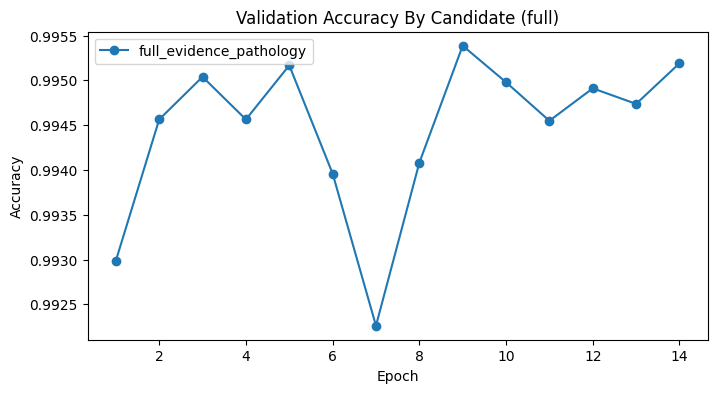

In [7]:
history_frames = []
for row in summary_frame.itertuples(index=False):
    history_path = Path(row.artifact_dir) / "training_history.json"
    history = pd.read_json(history_path)
    history["candidate_name"] = row.candidate_name
    history_frames.append(history)

history_frame = pd.concat(history_frames, ignore_index=True)
display(history_frame.groupby("candidate_name")[["accuracy", "macro_f1"]].max().sort_values("accuracy", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
for candidate_name, group in history_frame.groupby("candidate_name"):
    ax.plot(group["epoch"], group["accuracy"], marker="o", label=candidate_name)
ax.set_title(f"Validation Accuracy By Candidate ({RUN_MODE})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.show()


## Deduplicated Robustness Check

The official metrics are kept unchanged for comparability. This section adds a post-hoc robustness check that removes validation/test rows whose signatures appear in the training split, then recomputes metrics on the remaining rows. It reports both exact raw-row duplicates and a stricter feature-signature duplicate check based on `AGE`, `SEX`, `EVIDENCES`, and `INITIAL_EVIDENCE`.

In [8]:
def canonical_json_signature(row: dict[str, Any], columns: list[str]) -> str:
    payload = {column: row[column] for column in columns}
    return json.dumps(payload, sort_keys=True, default=str)


def add_signature_columns(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.copy()
    raw_columns = [column for column in enriched.columns if column not in {"source_row_index", "split", "case_id"}]
    feature_columns = ["AGE", "SEX", "EVIDENCES", "INITIAL_EVIDENCE"]
    enriched["raw_row_signature"] = [
        canonical_json_signature(row, raw_columns)
        for row in enriched.to_dict(orient="records")
    ]
    enriched["feature_signature"] = [
        canonical_json_signature(row, feature_columns)
        for row in enriched.to_dict(orient="records")
    ]
    return enriched


def load_trained_direct_model(artifact_dir: Path, schema: ObservationSchema, label_names: list[str], device: torch.device) -> nn.Module:
    checkpoint = torch.load(artifact_dir / "best_model.pt", map_location="cpu")
    resolved = checkpoint.get("resolved_run_config", {})
    model = DirectDiagnosisMLP(
        input_dim=schema.feature_size,
        hidden_sizes=list(resolved.get("hidden_sizes", BASE_RUN_CONFIG["hidden_sizes"])),
        num_classes=len(label_names),
        dropout=float(resolved.get("dropout", BASE_RUN_CONFIG["dropout"])),
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def recompute_metrics_for_subset(
    frame: pd.DataFrame,
    split_name: str,
    artifact_dir: Path,
    model: nn.Module,
    compiler: CaseEpisodeCompiler,
    pathology_to_index: dict[str, int],
    label_names: list[str],
    device: torch.device,
    objective_name: str,
) -> tuple[dict[str, Any], pd.DataFrame]:
    if len(frame) == 0:
        empty_metrics = {
            "num_rows": 0,
            "loss": None,
            "accuracy": None,
            "top3_accuracy": None,
            "top5_accuracy": None,
            "macro_f1": None,
        }
        return empty_metrics, pd.DataFrame()
    features, labels, differential_targets, metadata = encode_split(frame, compiler, pathology_to_index, split_name)
    loader = create_loader(
        features,
        labels,
        differential_targets,
        BASE_RUN_CONFIG["batch_size"],
        False,
        BASE_RUN_CONFIG["num_workers"],
    )
    probs, gold, gt_diff, loss = predict(model, loader, device, objective_name)
    metrics = compute_metrics(probs, gold, gt_diff, label_names)
    metrics = {"num_rows": int(len(frame)), "loss": float(loss), **metrics}
    prediction_frame = build_predictions_frame(probs, gold, metadata, label_names)
    return metrics, prediction_frame


train_signed = add_signature_columns(raw_train)
validate_signed = add_signature_columns(raw_validate)
test_signed = add_signature_columns(raw_test)
train_raw_signatures = set(train_signed["raw_row_signature"])
train_feature_signatures = set(train_signed["feature_signature"])

signed_splits = {
    "validate": validate_signed,
    "test": test_signed,
}

dedup_artifact_rows = []
selected_artifact_dir = Path(selection_payload["selected_artifact_dir"])
selected_candidate = summary_frame.iloc[0].candidate_name
selected_objective = CANDIDATE_CONFIGS[selected_candidate]["objective_name"]
model_for_dedup = load_trained_direct_model(selected_artifact_dir, schema, label_names, device)

for split_name, signed_frame in signed_splits.items():
    official_rows = int(len(signed_frame))
    raw_duplicate_mask = signed_frame["raw_row_signature"].isin(train_raw_signatures)
    feature_duplicate_mask = signed_frame["feature_signature"].isin(train_feature_signatures)
    raw_dedup_frame = signed_frame.loc[~raw_duplicate_mask].drop(columns=["raw_row_signature", "feature_signature"]).reset_index(drop=True)
    feature_dedup_frame = signed_frame.loc[~feature_duplicate_mask].drop(columns=["raw_row_signature", "feature_signature"]).reset_index(drop=True)

    for dedup_type, subset_frame, duplicate_mask in [
        ("raw_row_signature", raw_dedup_frame, raw_duplicate_mask),
        ("feature_signature", feature_dedup_frame, feature_duplicate_mask),
    ]:
        metrics, predictions = recompute_metrics_for_subset(
            frame=subset_frame,
            split_name=split_name,
            artifact_dir=selected_artifact_dir,
            model=model_for_dedup,
            compiler=compiler,
            pathology_to_index=pathology_to_index,
            label_names=label_names,
            device=device,
            objective_name=selected_objective,
        )
        duplicate_count = int(duplicate_mask.sum())
        payload = {
            "run_name": str(selected_artifact_dir.name),
            "split": split_name,
            "dedup_type": dedup_type,
            "official_rows": official_rows,
            "duplicate_rows_removed": duplicate_count,
            "deduplicated_rows": int(len(subset_frame)),
            "duplicate_fraction": float(duplicate_count / max(1, official_rows)),
            "metrics": metrics,
        }
        dedup_artifact_rows.append(payload)
        with (selected_artifact_dir / f"dedup_metrics_{split_name}_{dedup_type}.json").open("w", encoding="utf-8") as handle:
            json.dump(payload, handle, indent=2)
        if not predictions.empty:
            predictions.to_csv(selected_artifact_dir / f"dedup_predictions_{split_name}_{dedup_type}.csv", index=False)

summary_rows = []
for payload in dedup_artifact_rows:
    row = {
        "split": payload["split"],
        "dedup_type": payload["dedup_type"],
        "official_rows": payload["official_rows"],
        "duplicate_rows_removed": payload["duplicate_rows_removed"],
        "deduplicated_rows": payload["deduplicated_rows"],
        "duplicate_fraction": payload["duplicate_fraction"],
    }
    row.update({f"dedup_{key}": value for key, value in payload["metrics"].items() if isinstance(value, (int, float)) or value is None})
    summary_rows.append(row)

dedup_summary_frame = pd.DataFrame(summary_rows)
dedup_summary_frame.to_csv(selected_artifact_dir / "dedup_robustness_summary.csv", index=False)
with (selected_artifact_dir / "dedup_robustness_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(dedup_artifact_rows, handle, indent=2)

display(dedup_summary_frame)
print("Saved dedup robustness artifacts to:", selected_artifact_dir)

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/258753155.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(artifact_dir / "best_

Encoding validate:   0%|          | 0/130805 [00:00<?, ?it/s]

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


Encoding validate:   0%|          | 0/130640 [00:00<?, ?it/s]

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


...

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


Encoding test:   0%|          | 0/132540 [00:00<?, ?it/s]

/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:86: RuntimeWarning: invalid value encountered in divide
  ddf1 = np.where(ddr + ddp == 0, 0.0, 2 * ddr * ddp / (ddr + ddp))
/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_89523/342217905.py:107: RuntimeWarning: invalid value encountered in divide
  2 * recall_top * precision_top / (recall_top + precision_top),


,split,dedup_type,official_rows,duplicate_rows_removed,deduplicated_rows,duplicate_fraction,dedup_num_rows,dedup_loss,dedup_accuracy,dedup_top3_accuracy,...,dedup_macro_f1,dedup_DDR,dedup_DDP,dedup_DDF1,dedup_DDR@3,dedup_DDP@3,dedup_DDF1@3,dedup_DDR@5,dedup_DDP@5,dedup_DDF1@5
0,validate,raw_row_signature,132448,1643,130805,0.012405,130805,0.012270,0.995329,1.0,...,0.994291,0.213948,0.996068,0.308332,0.368215,0.923962,0.510543,0.279099,0.967836,0.406277
1,validate,feature_signature,132448,1808,130640,0.013651,130640,0.012285,0.995323,1.0,...,0.994291,0.213816,0.996063,0.308223,0.368101,0.923904,0.510447,0.278974,0.967810,0.406174
2,test,raw_row_signature,134529,1823,132706,0.013551,132706,0.011530,0.995758,1.0,...,0.994834,0.214299,0.995807,0.308745,0.368555,0.924782,0.511025,0.279428,0.968338,0.406707
3,test,feature_signature,134529,1989,132540,0.014785,132540,0.011545,0.995752,1.0,...,0.994834,0.214106,0.995801,0.308567,0.368403,0.924711,0.510895,0.279257,0.968298,0.406559


Saved dedup robustness artifacts to: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence/full_evidence_pathology_full


## Discussion

This notebook intentionally acts as an oracle-style information comparator. It answers whether DDXPlus contains enough structured evidence for high direct-diagnosis performance when the full case is visible.

It should not be treated as a fair live diagnostic policy, because the sequential agent does not get all evidence for free. Its role in later notebooks is to measure the remaining gap between targeted sequential evidence acquisition and the full-information ceiling.